In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [46]:
Level_df1 = pd.read_csv('Dispersion/GARCH MIDAS/Level_VIX_TermSpread_2-10Spread_VXN.csv')
Level_df2 = pd.read_csv('Dispersion/GARCH MIDAS/Level_VIX_TermSpread_2-10Spread_VXN.csv')
Quarterly_df = pd.read_csv('Dispersion/GARCH MIDAS/Quarterly_Rate_Housing_IndProd_Inflation_PPI_GDP.csv', index_col = ['Date'], parse_dates=True, date_format='%Y%Q')

In [56]:
First_Diff_df = pd.read_csv('Dispersion/GARCH MIDAS/First_Diff_UMich_UnemploymentRate.csv', index_col=['Date'])
First_Diff_df.index = pd.to_datetime(First_Diff_df.index).to_period('M')
First_Diff_df_Q = First_Diff_df.resample('Q').mean().round(3)
First_Diff_df_Q = First_Diff_df_Q.reindex(Quarterly_df.index)

/var/folders/2_/q3fhp8js4zgd2w2m2cb4y8rh0000gn/T/ipykernel_48575/791222429.py:3: FutureWarning: Resampling with a PeriodIndex is deprecated. Cast index to DatetimeIndex before resampling instead.
  First_Diff_df_Q = First_Diff_df.resample('Q').mean().round(3)


In [59]:
Quarterly_df_First_diff_df = Quarterly_df.merge(First_Diff_df_Q, left_index= True, right_index= True, how = 'outer')

In [72]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [125]:
n_components = 5
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Quarterly_df_First_diff_df)
PCA_ = PCA(n_components=n_components)
X_PCA = PCA_.fit_transform(X_scaled)
X_PCA = pd.DataFrame(X_PCA, columns=[f'PC{i+1}' for i in range(n_components)])


In [126]:
print(' Explained Variance :', PCA_.explained_variance_)
print(' Explained Variance Ratio :', PCA_.explained_variance_ratio_)
np.cumsum(PCA_.explained_variance_ratio_)
range(1, len(PCA_.explained_variance_ratio_ + 1))

 Explained Variance : [3.55754021 1.31647127 0.90266808 0.61315653 0.46689071]
 Explained Variance Ratio : [0.50194571 0.18574551 0.12736058 0.08651238 0.06587523]


range(1, 5)

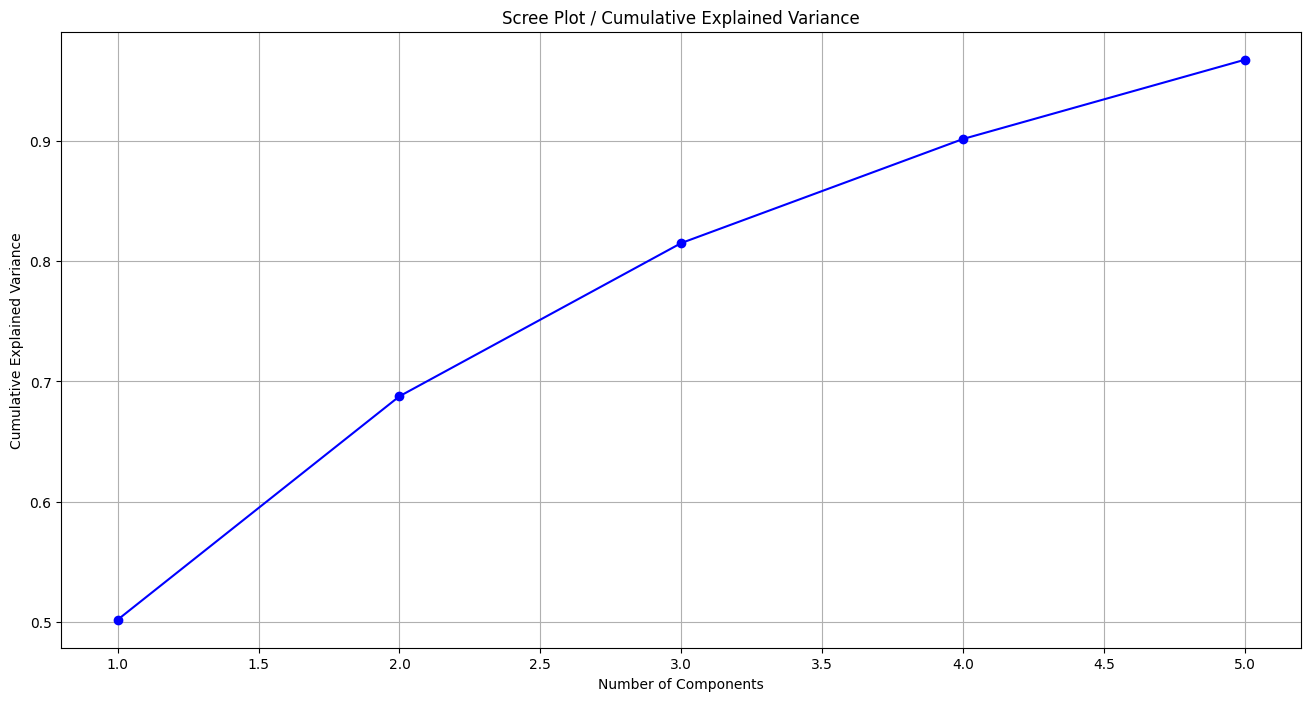

In [128]:
plt.figure(figsize = (16, 8))
plt.plot(
    range(1, len(PCA_.explained_variance_ratio_) + 1),
    np.cumsum(PCA_.explained_variance_ratio_),
    'bo-'
)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot / Cumulative Explained Variance')
plt.grid(True)
plt.show()

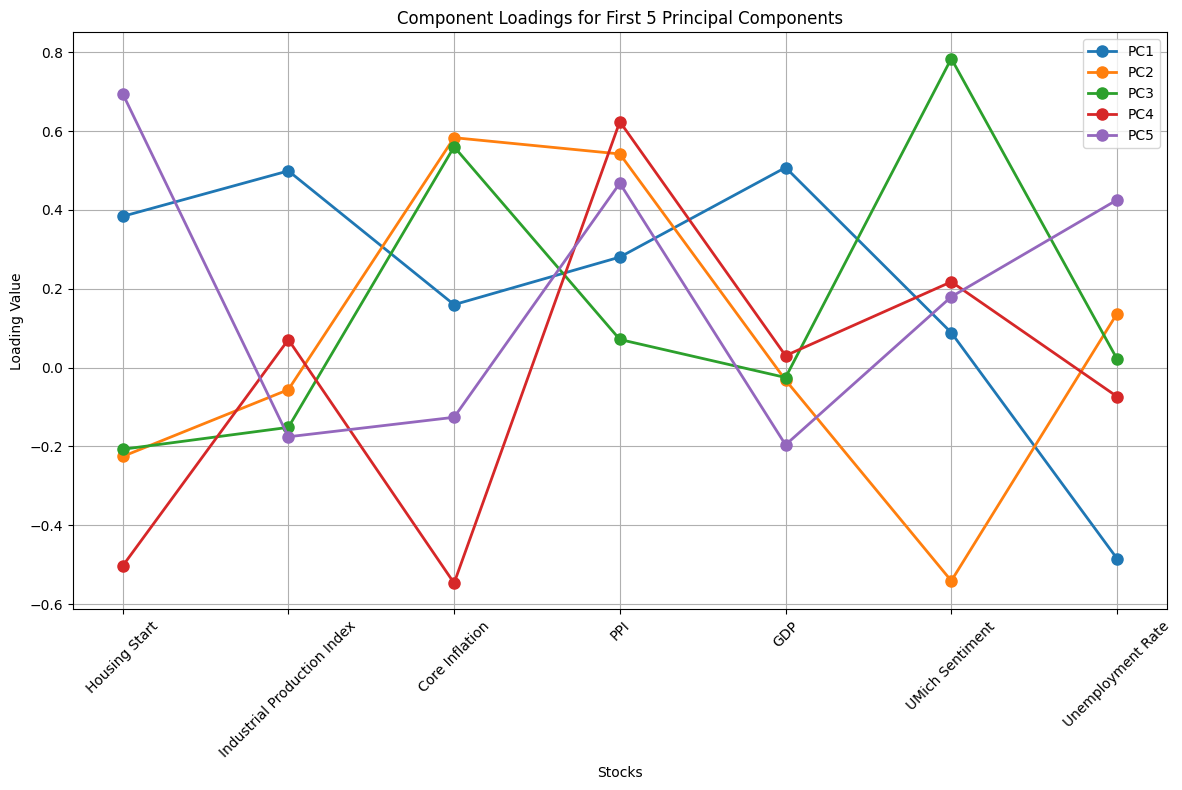

Top contributors to each principal component:

PC1 (variance explained : 0.5):
GDP: 0.507
Industrial Production Index: 0.499
Unemployment Rate: 0.485

PC2 (variance explained : 0.19):
Core Inflation: 0.583
PPI: 0.542
UMich Sentiment: 0.541

PC3 (variance explained : 0.13):
UMich Sentiment: 0.784
Core Inflation: 0.560
Housing Start: 0.207

PC4 (variance explained : 0.09):
PPI: 0.624
Core Inflation: 0.547
Housing Start: 0.503

PC5 (variance explained : 0.07):
Housing Start: 0.695
PPI: 0.467
Unemployment Rate: 0.425


In [ ]:
# Get component loadings
loadings = pd.DataFrame(
    PCA_.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=Quarterly_df_First_diff_df.columns
)

# Plot loadings for first 3 PCs on a single plot
plt.figure(figsize=(12, 8))
for i in range(n_components):
    plt.plot(loadings.index, loadings[f'PC{i+1}'], 
             marker='o', 
             linewidth=2, 
             markersize=8,
             label=f'PC{i+1}')

plt.title(f'Component Loadings for First {n_components} Principal Components')
plt.xlabel('Stocks')
plt.ylabel('Loading Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print top contributors for each PC
print("Top contributors to each principal component:")



In [119]:
US_sector_indices = pd.read_csv('Dispersion/GARCH MIDAS/Sector_Indices_2005_2025.csv', parse_dates=True, index_col = ['Date'])
US_indices = pd.read_csv('Dispersion/GARCH MIDAS/US_Indices_2005_2025.csv', parse_dates=True, index_col = ['Date'])

In [155]:
Contributor_Score = {}
for i in range(n_components):
    print(f"\nPC{i+1} (variance explained : {PCA_.explained_variance_ratio_[i].round(2)}):")
    top_contributors = loadings[f'PC{i+1}'].abs().sort_values(ascending=False).head(3)
    for stock, loading in top_contributors.items():
        print(f"{stock}: {loading:.3f}")
        if stock not in Contributor_Score.keys():
            Contributor_Score[stock] = loading * PCA_.explained_variance_ratio_[i]
        else:
            Contributor_Score[stock] = Contributor_Score[stock] + loading * PCA_.explained_variance_ratio_[i]
            



PC1 (variance explained : 0.5):
GDP: 0.507
Industrial Production Index: 0.499
Unemployment Rate: 0.485

PC2 (variance explained : 0.19):
Core Inflation: 0.583
PPI: 0.542
UMich Sentiment: 0.541

PC3 (variance explained : 0.13):
UMich Sentiment: 0.784
Core Inflation: 0.560
Housing Start: 0.207

PC4 (variance explained : 0.09):
PPI: 0.624
Core Inflation: 0.547
Housing Start: 0.503

PC5 (variance explained : 0.07):
Housing Start: 0.695
PPI: 0.467
Unemployment Rate: 0.425


In [164]:
sorted(Contributor_Score.items(), key=lambda x : -x[1])

[('Unemployment Rate', np.float64(0.2712872103366103)),
 ('GDP', np.float64(0.25468689011492834)),
 ('Industrial Production Index', np.float64(0.2504039052314164)),
 ('Core Inflation', np.float64(0.22691332994327218)),
 ('UMich Sentiment', np.float64(0.2003257398387832)),
 ('PPI', np.float64(0.18537927211755229)),
 ('Housing Start', np.float64(0.11575489817597776))]